# 02. ROSE and LROM Cross-Section Comparison

In [1]:
from pathlib import Path
import platform
import sys
import time

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from numba import njit

ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "lrom_legacy").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import scipy.special
if not hasattr(scipy.special, "sph_harm") and hasattr(scipy.special, "sph_harm_y"):
    scipy.special.sph_harm = (
        lambda m, n, theta, phi: scipy.special.sph_harm_y(n, m, phi, theta)
    )

import rose
import lrom_legacy.v2_0 as lrom

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})
print("lrom version:", lrom.__version__)


lrom version: 2.0.0


## 1. Physical Problem and Optical-Potential Parameters

In [2]:
TARGET = (40, 20)
PROJECTILE = (1, 0)
LAB_ENERGY = 14.1
L_MAX = 3
MESH_SIZE = 600
N_TRAIN = 200
N_TEST = 100
HALF_WIDTH = 0.20
ANGLES_DEG = np.arange(1.0, 180.0, 1.0)
ANGLES_RAD = np.deg2rad(ANGLES_DEG)
BASIS_SIZES = (4, 6, 8)
ROSE_EIM_SIZES = (4, 8, 12)
LROM_PREDICTOR_COUNTS = (4, 8, 12)
DEFAULT_BASIS_SIZE = 6
DEFAULT_COMPRESSION_SIZE = 8
TIMING_REPEATS = 3
SEED = 1204
ERROR_DENOMINATOR_FLOOR = 1e-12
PLOTTING_FLOOR = 1e-6


## 2. Shared Training and Testing Samples

In [3]:
emulator = lrom.LROM(
    target=TARGET,
    projectile=PROJECTILE,
    lab_energy=LAB_ENERGY,
    l=tuple(range(L_MAX + 1)),
    potential="full_woods-saxon",
)
central = dict(emulator.central_parameters)
ranges = {
    name: tuple(sorted(((1.0 - HALF_WIDTH) * value, (1.0 + HALF_WIDTH) * value)))
    for name, value in central.items()
}
emulator.sampling(
    training_ranges=ranges,
    testing_ranges=ranges,
    training_size=N_TRAIN,
    testing_size=N_TEST,
    mesh_size=MESH_SIZE,
    strategy="latin_hypercube",
    seed=SEED,
    high_fidelity_solver="runge_kutta",
    solver_options={"rk_tols": (1e-9, 1e-9)},
)
parameter_names = emulator.parameter_names
train_rows = emulator.samples.design.training.values.copy()
test_rows = emulator.samples.design.testing.values.copy()
train_ids = emulator.samples.design.training.case_ids
test_ids = emulator.samples.design.testing.case_ids

assert train_rows.shape == (N_TRAIN, len(parameter_names))
assert test_rows.shape == (N_TEST, len(parameter_names))
assert not any(np.array_equal(a, b) for a in train_rows for b in test_rows)
for column, name in enumerate(parameter_names):
    lower, upper = ranges[name]
    assert np.all((lower <= train_rows[:, column]) & (train_rows[:, column] <= upper))
    assert np.all((lower <= test_rows[:, column]) & (test_rows[:, column] <= upper))

rose_train_rows = train_rows
rose_test_rows = test_rows
assert np.array_equal(train_rows, rose_train_rows)
assert np.array_equal(test_rows, rose_test_rows)


def rows_as_parameter_dicts(rows):
    return [
        {name: float(value) for name, value in zip(parameter_names, row)}
        for row in rows
    ]


def pointwise_relative_error(predicted, reference):
    predicted = np.asarray(predicted, dtype=float)
    reference = np.asarray(reference, dtype=float)
    denominator = np.maximum(np.abs(reference), ERROR_DENOMINATOR_FLOOR)
    return np.abs(predicted - reference) / denominator


def error_summaries(predicted, reference):
    pointwise = pointwise_relative_error(predicted, reference)
    return {
        "median_error": np.median(pointwise, axis=1),
        "cat_error": np.max(pointwise_relative_error(predicted, reference), axis=1),
    }


def minimum_lrom_times(model, cases):
    model.predict(parameters=cases[:1])
    seconds = []
    for case in cases:
        repeats = []
        for _ in range(TIMING_REPEATS):
            start = time.perf_counter()
            model.predict(parameters=case)
            repeats.append(time.perf_counter() - start)
        seconds.append(min(repeats))
    return np.asarray(seconds)


def minimum_rose_times(model, rows):
    warm_splus, warm_sminus = emulated_smatrix_all_channels(model, rows[0])
    cross_section_from_smatrix(model, rows[0], warm_splus, warm_sminus)
    seconds = []
    for row in rows:
        repeats = []
        for _ in range(TIMING_REPEATS):
            start = time.perf_counter()
            splus, sminus = emulated_smatrix_all_channels(model, row)
            cross_section_from_smatrix(model, row, splus, sminus)
            repeats.append(time.perf_counter() - start)
        seconds.append(min(repeats))
    return np.asarray(seconds)


LS_LABEL = "LS-projected cross section"


## 3. Potential Variation and LROM Predictor Locations

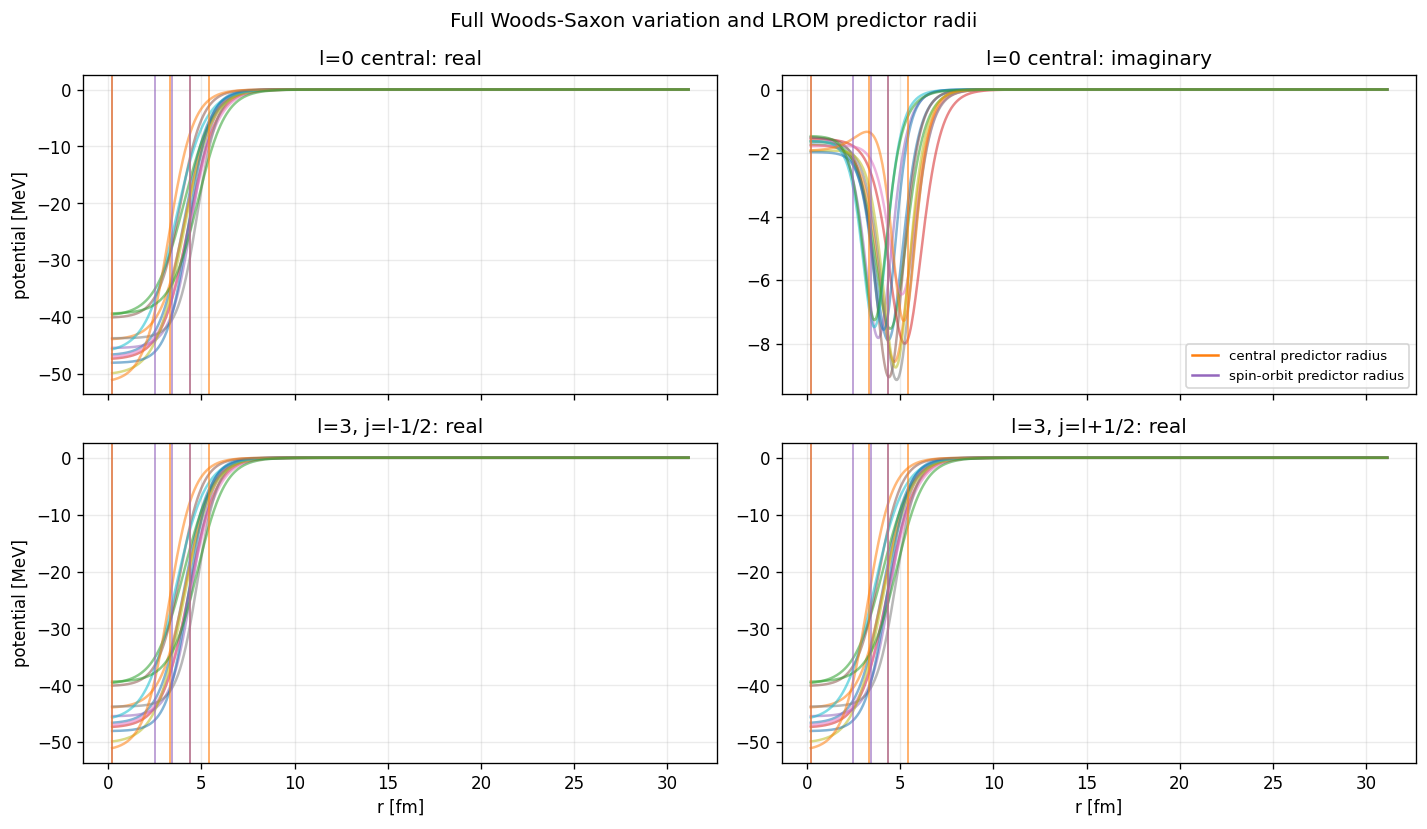

In [4]:
# FIGURE: potential-predictor-rainbows
radius_mesh = emulator.samples.mesh.radius
radius_mask = radius_mesh >= 0.2
plot_radius = radius_mesh[radius_mask]
section3_predictor = lrom.build_potential_predictor(
    radius=radius_mesh,
    central_potential=emulator.samples.central_potential,
    training_potentials=emulator.samples.training_potentials,
    testing_potentials=emulator.samples.testing_potentials,
    predictor_count=DEFAULT_COMPRESSION_SIZE,
    minimum_radius=0.2,
    central_spin_orbit=emulator.samples.central_spin_orbit,
    training_spin_orbit=emulator.samples.training_spin_orbit,
    testing_spin_orbit=emulator.samples.testing_spin_orbit,
)

center_vector = np.asarray([central[name] for name in parameter_names])
range_scale = np.asarray([ranges[name][1] - ranges[name][0] for name in parameter_names])
standardized_distance = np.linalg.norm(
    (test_rows - center_vector[np.newaxis, :]) / range_scale[np.newaxis, :],
    axis=1,
)
ranked = np.argsort(standardized_distance)
rainbow_indices = ranked[np.linspace(0, len(ranked) - 1, 12, dtype=int)]
rainbow_rows = np.vstack([center_vector, test_rows[rainbow_indices]])

fig, axes = plt.subplots(2, 2, figsize=(12.0, 7.0), sharex=True)
for row in rainbow_rows:
    central_part = lrom.full_woods_saxon(radius_mesh, row)
    spin_orbit_part = lrom.full_woods_saxon_spin_orbit(radius_mesh, row)
    axes[0, 0].plot(plot_radius, central_part.real[radius_mask], alpha=0.55)
    axes[0, 1].plot(plot_radius, central_part.imag[radius_mask], alpha=0.55)
    l_minus_part = central_part - 0.5 * (L_MAX + 1) * spin_orbit_part
    l_plus_part = central_part + 0.5 * L_MAX * spin_orbit_part
    axes[1, 0].plot(
        plot_radius,
        l_minus_part.real[radius_mask],
        alpha=0.55,
    )
    axes[1, 1].plot(
        plot_radius,
        l_plus_part.real[radius_mask],
        alpha=0.55,
    )

component_colors = {0: "tab:orange", 1: "tab:purple"}
for radius, component in zip(
    section3_predictor.selected_radii,
    section3_predictor.selected_components,
):
    color = component_colors[int(component)]
    for ax in axes.flat:
        ax.axvline(radius, color=color, alpha=0.7, lw=1.0)

axes[0, 0].set_title("l=0 central: real")
axes[0, 1].set_title("l=0 central: imaginary")
axes[1, 0].set_title("l=3, j=l-1/2: real")
axes[1, 1].set_title("l=3, j=l+1/2: real")
for ax in axes[1]:
    ax.set_xlabel("r [fm]")
for ax in axes[:, 0]:
    ax.set_ylabel("potential [MeV]")
axes[0, 1].legend(
    handles=[
        Line2D([], [], color="tab:orange", label="central predictor radius"),
        Line2D([], [], color="tab:purple", label="spin-orbit predictor radius"),
    ],
    fontsize=8,
)
fig.suptitle("Full Woods-Saxon variation and LROM predictor radii")
fig.tight_layout()
plt.show()

assert np.all(section3_predictor.selected_radii >= radius_mesh.min())
assert np.all(section3_predictor.selected_radii <= radius_mesh.max())


## 4. Equal-Basis ROSE and LROM Emulators

In [5]:
@njit
def bench_ws(r, radius, diffuseness):
    return 1.0 / (1.0 + np.exp((r - radius) / diffuseness))


@njit
def bench_ws_prime(r, radius, diffuseness):
    ex = np.exp((r - radius) / diffuseness)
    return -(ex / diffuseness) / (1.0 + ex) ** 2


@njit
def bench_full_ws(r, alpha):
    vv, wv, wd, _vso, rv, rd, _rso, av, ad, _aso = alpha
    return (
        -vv * bench_ws(r, rv, av)
        - 1j * wv * bench_ws(r, rv, av)
        + 4j * ad * wd * bench_ws_prime(r, rd, ad)
    )


@njit
def bench_full_ws_so(r, alpha, ldots):
    _vv, _wv, _wd, vso, _rv, _rd, rso, _av, _ad, aso = alpha
    return vso / 139.57039**2 * ldots * bench_ws_prime(r, rso, aso) / r


rho_mesh = emulator.samples.mesh.rho
radius_mesh = emulator.samples.mesh.radius
rose_solver = rose.SchroedingerEquation.make_base_solver(
    s_0=6 * np.pi,
    rk_tols=[1e-9, 1e-9],
    domain=np.array([rho_mesh[0], rho_mesh[-1]]),
)


def _channel_key(ell, spin_index, interaction_row):
    return ell if len(interaction_row) == 1 else (ell, spin_index)


def build_rose_bases(interaction, n_phi):
    bases = []
    for ell, interaction_row in enumerate(interaction.interactions):
        row_bases = []
        for spin_index, _ in enumerate(interaction_row):
            key = _channel_key(ell, spin_index, interaction_row)
            model = emulator.samples.full_order_models[key]
            free_reference = np.asarray(
                [
                    rose.free_solutions.phi_free(
                        float(s), ell, emulator.kinematics.eta
                    )
                    for s in rho_mesh
                ],
                dtype=np.complex128,
            )
            row_bases.append(
                rose.basis.CustomBasis(
                    solutions=np.asarray(
                        emulator.samples.training_wavefunctions[key],
                        dtype=np.complex128,
                    ).T.copy(),
                    phi_0=free_reference,
                    rho_mesh=rho_mesh,
                    n_basis=n_phi,
                    solver=model.solver,
                    subtract_phi0=True,
                    use_svd=True,
                    center=False,
                    scale=False,
                )
            )
        bases.append(row_bases)
    return bases


def build_rose_emulator(interaction, n_phi):
    return rose.ScatteringAmplitudeEmulator(
        interaction,
        build_rose_bases(interaction, n_phi),
        l_max=L_MAX,
        angles=ANGLES_RAD,
        s_0=rose_solver.s_0,
        Smatrix_abs_tol=1e-8,
        initialize_emulator=True,
    )


def exact_smatrix_all_channels(sae, row):
    splus = np.empty(len(sae.rbes), dtype=np.complex128)
    sminus = np.empty_like(splus)
    for ell, rbe_row in enumerate(sae.rbes):
        splus[ell] = rbe_row[0].basis.solver.smatrix(row)
        sminus[ell] = (
            splus[ell]
            if ell == 0
            else rbe_row[1].basis.solver.smatrix(row)
        )
    return splus, sminus


def emulated_smatrix_all_channels(sae, row):
    splus = np.empty(len(sae.rbes), dtype=np.complex128)
    sminus = np.empty_like(splus)
    for ell, rbe_row in enumerate(sae.rbes):
        splus[ell] = rbe_row[0].S_matrix_element(row)
        sminus[ell] = (
            splus[ell]
            if ell == 0
            else rbe_row[1].S_matrix_element(row)
        )
    return splus, sminus


def cross_section_from_smatrix(sae, row, splus, sminus):
    return sae.calculate_xs(
        splus,
        sminus,
        row,
        angles=ANGLES_RAD,
    ).dsdo


rose_emulators = {}
for n_phi in BASIS_SIZES:
    for n_u in ROSE_EIM_SIZES:
        interaction = rose.InteractionEIMSpace(
            l_max=L_MAX,
            coordinate_space_potential=bench_full_ws,
            spin_orbit_term=bench_full_ws_so,
            n_theta=len(parameter_names),
            mu=emulator.kinematics.mu,
            energy=emulator.kinematics.e_com,
            is_complex=True,
            training_info=rose_train_rows,
            explicit_training=True,
            n_basis=n_u,
            rho_mesh=rho_mesh,
        )
        rose_emulators[(n_phi, n_u)] = build_rose_emulator(
            interaction,
            n_phi,
        )

reference_sae = rose_emulators[(BASIS_SIZES[0], ROSE_EIM_SIZES[0])]
fom_train_xs = np.asarray(
    [
        cross_section_from_smatrix(
            reference_sae,
            row,
            *exact_smatrix_all_channels(reference_sae, row),
        )
        for row in train_rows
    ]
)
fom_test_xs = np.asarray(
    [
        cross_section_from_smatrix(
            reference_sae,
            row,
            *exact_smatrix_all_channels(reference_sae, row),
        )
        for row in test_rows
    ]
)
assert len(reference_sae.rbes) == L_MAX + 1
assert fom_train_xs.shape == (N_TRAIN, ANGLES_DEG.size)
assert fom_test_xs.shape == (N_TEST, ANGLES_DEG.size)
assert np.all(np.isfinite(fom_train_xs)) and np.all(fom_train_xs >= -1e-12)
assert np.all(np.isfinite(fom_test_xs)) and np.all(fom_test_xs >= -1e-12)


train_cases = rows_as_parameter_dicts(train_rows)
test_cases = rows_as_parameter_dicts(test_rows)
lrom_results = {}
ls_results = {}
default_predictor = None

for n_phi in BASIS_SIZES:
    for predictor_count in LROM_PREDICTOR_COUNTS:
        emulator.train(
            basis_size=n_phi,
            predictor="potential",
            predictor_count=predictor_count,
            observable="cross_section",
            angles_degrees=ANGLES_DEG,
        )
        test_seconds = minimum_lrom_times(emulator, test_cases)
        emulator.predict(parameters=train_cases)
        train_xs = emulator.predictions.cross_sections.values.copy()
        emulator.predict(parameters=test_cases)
        test_xs = emulator.predictions.cross_sections.values.copy()
        train_summary = error_summaries(train_xs, fom_train_xs)
        test_summary = error_summaries(test_xs, fom_test_xs)
        lrom_results[(n_phi, predictor_count)] = {
            "train_xs": train_xs,
            "test_xs": test_xs,
            "train_median_error": train_summary["median_error"],
            "test_median_error": test_summary["median_error"],
            "train_cat_error": train_summary["cat_error"],
            "test_cat_error": test_summary["cat_error"],
            "test_seconds": test_seconds,
        }

        if (n_phi, predictor_count) == (
            DEFAULT_BASIS_SIZE,
            DEFAULT_COMPRESSION_SIZE,
        ):
            default_predictor = emulator.predictors

        if predictor_count == LROM_PREDICTOR_COUNTS[0]:
            ls_train_coordinates = {
                channel: lrom.project_coordinates(
                    basis=emulator.basis[channel],
                    wavefunctions=emulator.samples.training_wavefunctions[channel],
                )
                for channel in emulator.basis
            }
            ls_test_coordinates = {
                channel: lrom.project_coordinates(
                    basis=emulator.basis[channel],
                    wavefunctions=emulator.samples.testing_wavefunctions[channel],
                )
                for channel in emulator.basis
            }
            _, ls_train_state = lrom._cross_section_prediction(
                emulator=emulator,
                values=train_rows,
                coefficients=ls_train_coordinates,
            )
            _, ls_test_state = lrom._cross_section_prediction(
                emulator=emulator,
                values=test_rows,
                coefficients=ls_test_coordinates,
            )
            ls_train_summary = error_summaries(ls_train_state.values, fom_train_xs)
            ls_test_summary = error_summaries(ls_test_state.values, fom_test_xs)
            ls_results[n_phi] = {
                "train_xs": ls_train_state.values.copy(),
                "test_xs": ls_test_state.values.copy(),
                "train_median_error": ls_train_summary["median_error"],
                "test_median_error": ls_test_summary["median_error"],
                "train_cat_error": ls_train_summary["cat_error"],
                "test_cat_error": ls_test_summary["cat_error"],
            }

assert default_predictor is not None


rose_results = {}
for config, rose_emulator in rose_emulators.items():
    test_seconds = minimum_rose_times(rose_emulator, test_rows)
    train_xs = np.asarray(
        [
            cross_section_from_smatrix(
                rose_emulator,
                row,
                *emulated_smatrix_all_channels(rose_emulator, row),
            )
            for row in train_rows
        ]
    )
    test_xs = np.asarray(
        [
            cross_section_from_smatrix(
                rose_emulator,
                row,
                *emulated_smatrix_all_channels(rose_emulator, row),
            )
            for row in test_rows
        ]
    )
    train_summary = error_summaries(train_xs, fom_train_xs)
    test_summary = error_summaries(test_xs, fom_test_xs)
    rose_results[config] = {
        "train_xs": train_xs,
        "test_xs": test_xs,
        "train_median_error": train_summary["median_error"],
        "test_median_error": test_summary["median_error"],
        "train_cat_error": train_summary["cat_error"],
        "test_cat_error": test_summary["cat_error"],
        "test_seconds": test_seconds,
    }

for collection in (lrom_results, rose_results, ls_results):
    for result in collection.values():
        for values in result.values():
            assert np.all(np.isfinite(values))

assert set(lrom_results) == {
    (n_phi, predictor_count)
    for n_phi in BASIS_SIZES
    for predictor_count in LROM_PREDICTOR_COUNTS
}
assert set(rose_results) == {
    (n_phi, n_u)
    for n_phi in BASIS_SIZES
    for n_u in ROSE_EIM_SIZES
}


assert np.array_equal(
    default_predictor.selected_indices,
    section3_predictor.selected_indices,
)
assert np.array_equal(
    default_predictor.selected_components,
    section3_predictor.selected_components,
)


## 5. Representative Cross-Section Predictions

,selection,case_id,Vv,Wv,Wd,Vso,Rv,Rd,Rso,av,ad,aso
0,alpha selection A,test-0068,49.415472,1.904636,7.859587,6.898409,3.894783,4.598049,3.734482,0.567570,0.575590,0.705985
1,alpha selection B,test-0047,48.448934,1.382060,5.846968,6.156962,3.705071,4.721749,2.876222,0.778570,0.621436,0.627283
2,alpha selection C,test-0028,40.622930,1.678147,8.451520,5.011483,3.998330,5.267464,3.663396,0.623875,0.595767,0.568424


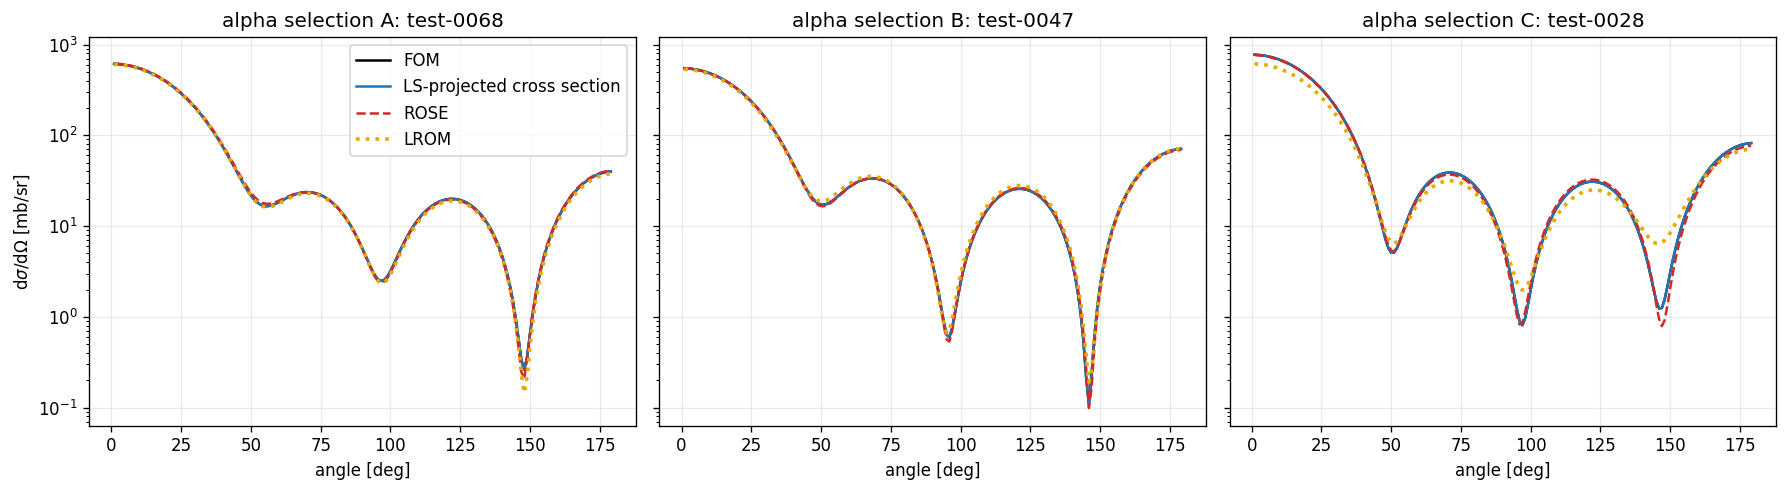

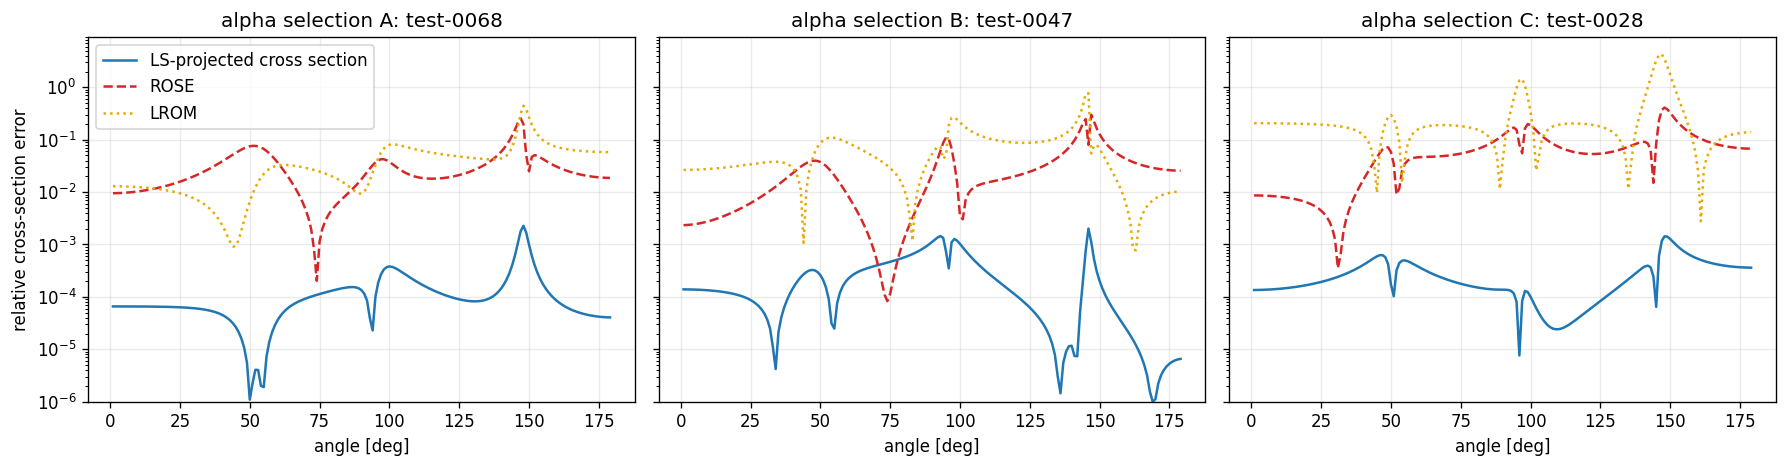

In [6]:
default_key = (DEFAULT_BASIS_SIZE, DEFAULT_COMPRESSION_SIZE)
lrom_rank = np.argsort(np.argsort(lrom_results[default_key]["test_cat_error"]))
rose_rank = np.argsort(np.argsort(rose_results[default_key]["test_cat_error"]))
combined_rank = 0.5 * (lrom_rank + rose_rank)
ordered_combined = np.argsort(combined_rank)
selection_positions = np.linspace(
    0,
    len(ordered_combined) - 1,
    5,
    dtype=int,
)[1:4]
selected_indices = [
    int(ordered_combined[position])
    for position in selection_positions
]
assert len(set(selected_indices)) == 3
selected_labels = (
    "alpha selection A",
    "alpha selection B",
    "alpha selection C",
)
alpha_selection_table = pd.DataFrame(
    [
        {
            "selection": label,
            "case_id": test_ids[index],
            **{
                name: float(test_rows[index, column])
                for column, name in enumerate(parameter_names)
            },
        }
        for label, index in zip(selected_labels, selected_indices)
    ]
)
display(alpha_selection_table)

# FIGURE: representative-cross-sections
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.2), sharey=True)
for ax, index, label in zip(axes, selected_indices, selected_labels):
    ax.semilogy(ANGLES_DEG, fom_test_xs[index], color="black", label="FOM")
    ax.semilogy(
        ANGLES_DEG,
        ls_results[DEFAULT_BASIS_SIZE]["test_xs"][index],
        color="tab:blue",
        label=LS_LABEL,
    )
    ax.semilogy(
        ANGLES_DEG,
        rose_results[default_key]["test_xs"][index],
        "--",
        color="tab:red",
        label="ROSE",
    )
    ax.semilogy(
        ANGLES_DEG,
        lrom_results[default_key]["test_xs"][index],
        ":",
        color="#E6AB02",
        lw=2.2,
        label="LROM",
    )
    ax.set_title(f"{label}: {test_ids[index]}")
    ax.set_xlabel("angle [deg]")
axes[0].set_ylabel(r"d$\sigma$/d$\Omega$ [mb/sr]")
axes[0].legend()
fig.tight_layout()
plt.show()

# FIGURE: cross-section-errors
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.0), sharey=True)
for ax, index, label in zip(axes, selected_indices, selected_labels):
    for values, method, color, style in (
        (
            ls_results[DEFAULT_BASIS_SIZE]["test_xs"],
            LS_LABEL,
            "tab:blue",
            "-",
        ),
        (rose_results[default_key]["test_xs"], "ROSE", "tab:red", "--"),
        (lrom_results[default_key]["test_xs"], "LROM", "#E6AB02", ":"),
    ):
        errors = pointwise_relative_error(values[index], fom_test_xs[index])
        ax.semilogy(
            ANGLES_DEG,
            np.maximum(errors, PLOTTING_FLOOR),
            style,
            color=color,
            label=method,
        )
    ax.set_title(f"{label}: {test_ids[index]}")
    ax.set_xlabel("angle [deg]")
axes[0].set_ylim(bottom=PLOTTING_FLOOR)
axes[0].set_ylabel("relative cross-section error")
axes[0].legend()
fig.tight_layout()
plt.show()


## 6. Cross-Section Error Distributions

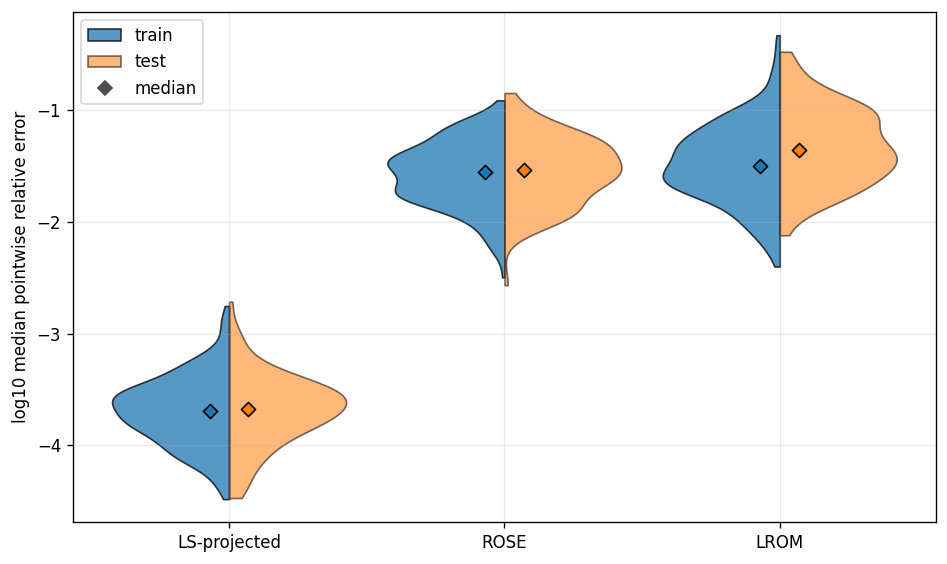

In [7]:
# FIGURE: error-violins
categories = (
    ("LS-projected", ls_results[DEFAULT_BASIS_SIZE]),
    ("ROSE", rose_results[default_key]),
    ("LROM", lrom_results[default_key]),
)
positions = np.arange(1, len(categories) + 1)
fig, ax = plt.subplots(figsize=(8.0, 4.8))
for center_pos, (label, result) in zip(positions, categories):
    for side, key, color, alpha in (
        (-1, "train_median_error", "tab:blue", 0.75),
        (+1, "test_median_error", "tab:orange", 0.55),
    ):
        values = np.log10(np.clip(result[key], PLOTTING_FLOOR, None))
        parts = ax.violinplot(
            [values],
            positions=[center_pos],
            widths=0.85,
            showextrema=False,
        )
        body = parts["bodies"][0]
        vertices = body.get_paths()[0].vertices
        vertices[:, 0] = (
            np.minimum(vertices[:, 0], center_pos)
            if side < 0
            else np.maximum(vertices[:, 0], center_pos)
        )
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(alpha)
        ax.scatter(
            center_pos + 0.07 * side,
            np.median(values),
            marker="D",
            color=color,
            edgecolor="black",
            zorder=6,
        )
ax.set_xticks(positions, [label for label, _ in categories])
ax.set_ylabel("log10 median pointwise relative error")
ax.legend(
    handles=[
        Patch(facecolor="tab:blue", alpha=0.75, edgecolor="black", label="train"),
        Patch(facecolor="tab:orange", alpha=0.55, edgecolor="black", label="test"),
        Line2D([], [], marker="D", linestyle="None", color="0.3", label="median"),
    ]
)
fig.tight_layout()
plt.show()


## 7. Basis and Operator-Size Comparison

In [8]:
summary_rows = []
for (n_phi, compression), result in rose_results.items():
    summary_rows.append(
        {
            "method": "ROSE",
            "n_phi": n_phi,
            "compression symbol": "n_U",
            "compression": compression,
            "median test error": float(np.median(result["test_median_error"])),
            "median CAT error": float(np.median(result["test_cat_error"])),
            "median online time [s]": float(np.median(result["test_seconds"])),
        }
    )
for (n_phi, compression), result in lrom_results.items():
    summary_rows.append(
        {
            "method": "LROM",
            "n_phi": n_phi,
            "compression symbol": "K",
            "compression": compression,
            "median test error": float(np.median(result["test_median_error"])),
            "median CAT error": float(np.median(result["test_cat_error"])),
            "median online time [s]": float(np.median(result["test_seconds"])),
        }
    )
summary_table = pd.DataFrame(summary_rows).sort_values(
    ["method", "n_phi", "compression"]
)
summary_table


,method,n_phi,compression symbol,compression,median test error,median CAT error,median online time [s]
9,LROM,4,K,4,0.183727,2.693571,0.000142
10,LROM,4,K,8,0.040925,0.615804,0.000142
11,LROM,4,K,12,0.006482,0.100912,0.000144
12,LROM,6,K,4,0.220882,4.018549,0.000146
13,LROM,6,K,8,0.043529,0.704439,0.000149
14,LROM,6,K,12,0.007480,0.092817,0.000239
15,LROM,8,K,4,0.199635,5.494174,0.000168
16,LROM,8,K,8,0.047335,0.889995,0.000159
17,LROM,8,K,12,0.005522,0.083764,0.000178
0,ROSE,4,n_U,4,0.110502,1.880423,0.000114


## 8. Accuracy Versus Online Time

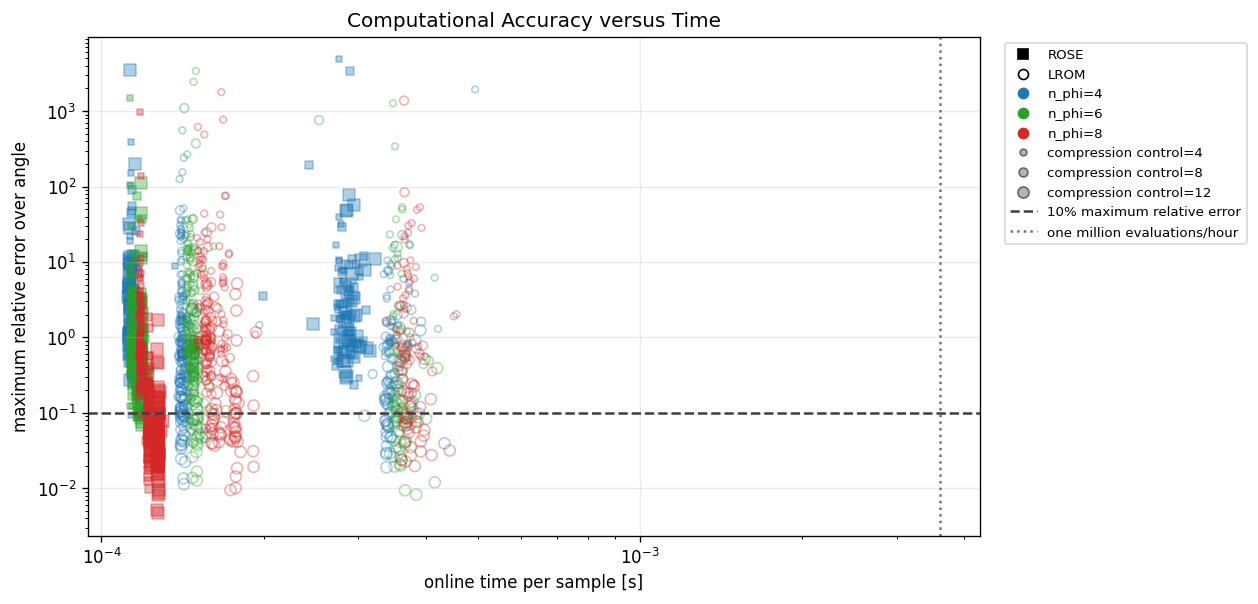

In [9]:
# FIGURE: cat-plot
fig, ax = plt.subplots(figsize=(12.5, 5.4))
colors = {4: "tab:blue", 6: "tab:green", 8: "tab:red"}
compression_sizes = {4: 16, 8: 28, 12: 44}
for (n_phi, n_u), result in rose_results.items():
    ax.scatter(
        result["test_seconds"],
        np.maximum(result["test_cat_error"], PLOTTING_FLOOR),
        marker="s",
        s=compression_sizes[n_u],
        alpha=0.35,
        color=colors[n_phi],
    )
for (n_phi, predictor_count), result in lrom_results.items():
    ax.scatter(
        result["test_seconds"],
        np.maximum(result["test_cat_error"], PLOTTING_FLOOR),
        marker="o",
        s=compression_sizes[predictor_count],
        alpha=0.35,
        facecolors="none",
        edgecolors=colors[n_phi],
    )
ax.axhline(0.10, color="0.25", linestyle="--")
ax.axvline(3600 / 1_000_000, color="0.45", linestyle=":")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("online time per sample [s]")
ax.set_ylabel("maximum relative error over angle")
ax.set_title("Computational Accuracy versus Time")

cat_handles = [
    Line2D(
        [], [],
        marker="s",
        linestyle="None",
        color="black",
        markerfacecolor="black",
        label="ROSE",
    ),
    Line2D(
        [], [],
        marker="o",
        linestyle="None",
        color="black",
        markerfacecolor="none",
        label="LROM",
    ),
]
cat_handles.extend(
    Line2D(
        [], [],
        marker="o",
        linestyle="None",
        color=color,
        markerfacecolor=color,
        label=f"n_phi={n_phi}",
    )
    for n_phi, color in colors.items()
)
cat_handles.extend(
    Line2D(
        [], [],
        marker="o",
        markersize=np.sqrt(size),
        linestyle="None",
        color="0.4",
        markerfacecolor="0.7",
        label=f"compression control={compression}",
    )
    for compression, size in compression_sizes.items()
)
cat_handles.extend(
    [
        Line2D(
            [], [],
            color="0.25",
            linestyle="--",
            label="10% maximum relative error",
        ),
        Line2D(
            [], [],
            color="0.45",
            linestyle=":",
            label="one million evaluations/hour",
        ),
    ]
)
ax.legend(
    handles=cat_handles,
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    fontsize=8,
)
fig.subplots_adjust(right=0.72)
plt.show()


## 9. Validation Summary

In [10]:
# TABLE: validation-summary
validation_summary = pd.DataFrame(
    [
        {"check": "training rows", "value": train_rows.shape},
        {"check": "testing rows", "value": test_rows.shape},
        {
            "check": "ROSE/LROM shared rows",
            "value": np.array_equal(train_rows, rose_train_rows)
            and np.array_equal(test_rows, rose_test_rows),
        },
        {"check": "partial waves", "value": tuple(range(L_MAX + 1))},
        {"check": "parameter half-width", "value": HALF_WIDTH},
        {"check": "basis sizes", "value": BASIS_SIZES},
        {"check": "ROSE EIM sizes", "value": ROSE_EIM_SIZES},
        {"check": "LROM predictor counts", "value": LROM_PREDICTOR_COUNTS},
        {"check": "Python", "value": sys.version.split()[0]},
        {"check": "platform", "value": platform.platform()},
    ]
)
validation_summary


,check,value
0,training rows,"(200, 10)"
1,testing rows,"(100, 10)"
2,ROSE/LROM shared rows,True
3,partial waves,"(0, 1, 2, 3)"
4,parameter half-width,0.2
5,basis sizes,"(4, 6, 8)"
6,ROSE EIM sizes,"(4, 8, 12)"
7,LROM predictor counts,"(4, 8, 12)"
8,Python,3.12.9
9,platform,macOS-15.7.7-arm64-arm-64bit
